# Aula: Revisão de Pandas e Introdução à Visualização de Dados

## Tema da aula

Nesta aula, vamos revisar conceitos importantes de **Pandas** e começar a trabalhar com **visualização de dados** usando:

- Matplotlib
- Seaborn

A ideia principal é aprender a transformar uma base de dados em **informações visuais úteis**, capazes de ajudar na tomada de decisão.

---

## Situação-problema

Imagine que uma empresa possui uma base de vendas, mas os dados estão em formato de tabela e não são fáceis de interpretar rapidamente.

A missão é usar Python para responder perguntas como:

- Qual categoria vende mais?
- Quais produtos geram mais receita?
- Existe relação entre preço e quantidade vendida?
- Há valores fora do padrão?
- Como podemos apresentar essas informações de forma visual?

Durante a aula, vamos simular esse cenário.

# 1. Importando as bibliotecas

Antes de começar, precisamos importar as bibliotecas que serão usadas.

- `pandas`: para carregar, organizar e analisar dados em tabelas.
- `matplotlib.pyplot`: para criar gráficos de forma mais manual.
- `seaborn`: para criar gráficos estatísticos com aparência mais pronta e sintaxe mais simples.

In [8]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Criando uma base de dados de exemplo

Para esta aula, vamos criar uma base simples de vendas.

Em uma situação real, normalmente carregaríamos um arquivo `.csv`, mas criar uma base dentro do próprio notebook facilita a revisão inicial.

In [21]:
dados = {
    "produto": [
        "Notebook", "Mouse", "Teclado", "Monitor", "Cadeira",
        "Mesa", "Headset", "Webcam", "Notebook", "Mouse",
        "Teclado", "Monitor", "Cadeira", "Mesa", "Headset",
        "Webcam", "Notebook", "Mouse", "Teclado", "Monitor"
    ],
    "categoria": [
        "Informática", "Periféricos", "Periféricos", "Informática", "Móveis",
        "Móveis", "Periféricos", "Periféricos", "Informática", "Periféricos",
        "Periféricos", "Informática", "Móveis", "Móveis", "Periféricos",
        "Periféricos", "Informática", "Periféricos", "Periféricos", "Informática"
    ],
    "preco": [
        3500, 80, 150, 1200, 700,
        900, 250, 300, 4200, 90,
        170, 1400, 850, 1000, 280,
        320, 3900, 75, 160, 1300
    ],
    "quantidade": [
        2, 15, 10, 4, 5,
        3, 8, 6, 1, 20,
        12, 3, 4, 2, 10,
        5, 2, 18, 11, 4
    ],
    "mes": [
        "Janeiro", "Janeiro", "Janeiro", "Janeiro", "Janeiro",
        "Fevereiro", "Fevereiro", "Fevereiro", "Fevereiro", "Fevereiro",
        "Março", "Março", "Março", "Março", "Abril",
        "Abril", "Abril", "Abril", "Abril", "Abril"
    ]
}

df = pd.DataFrame(dados)
df

,produto,categoria,preco,quantidade,mes
0,Notebook,Informática,3500,2,Janeiro
1,Mouse,Periféricos,80,15,Janeiro
2,Teclado,Periféricos,150,10,Janeiro
3,Monitor,Informática,1200,4,Janeiro
4,Cadeira,Móveis,700,5,Janeiro
5,Mesa,Móveis,900,3,Fevereiro
6,Headset,Periféricos,250,8,Fevereiro
7,Webcam,Periféricos,300,6,Fevereiro
8,Notebook,Informática,4200,1,Fevereiro
9,Mouse,Periféricos,90,20,Fevereiro


# 3. Revisão de Pandas

## 3.1 Visualizando as primeiras linhas

O método `.head()` mostra as primeiras linhas do DataFrame.

Ele é muito usado para entender rapidamente a estrutura da base.

In [8]:
df.head()

,produto,categoria,preco,quantidade,mes
0,Notebook,Informática,3500,2,Janeiro
1,Mouse,Periféricos,80,15,Janeiro
2,Teclado,Periféricos,150,10,Janeiro
3,Monitor,Informática,1200,4,Janeiro
4,Cadeira,Móveis,700,5,Janeiro


## 3.2 Visualizando as últimas linhas

O método `.tail()` mostra as últimas linhas da base.

In [ ]:
df.tail()

## 3.3 Informações gerais da base

O método `.info()` mostra:

- quantidade de linhas;
- quantidade de colunas;
- nomes das colunas;
- tipos de dados;
- valores não nulos.

In [ ]:
df.info()

## 3.4 Estatísticas descritivas

O método `.describe()` calcula estatísticas básicas para colunas numéricas:

- média;
- desvio padrão;
- valor mínimo;
- quartis;
- valor máximo.

In [13]:
df.describe()

,preco,quantidade
count,20.000000,20.000000
mean,1041.250000,7.250000
std,1296.937562,5.580747
min,75.000000,1.000000
25%,167.500000,3.000000
50%,510.000000,5.000000
75%,1225.000000,10.250000
max,4200.000000,20.000000


## 3.5 Verificando valores nulos

Antes de analisar uma base, é importante verificar se existem valores ausentes.

In [3]:
df.isnull().sum()

produto       0
categoria     0
preco         0
quantidade    0
mes           0
dtype: int64

## 3.6 Criando uma nova coluna

Vamos criar uma coluna chamada `faturamento`.

Ela será calculada multiplicando o preço pela quantidade vendida.

Essa é uma prática comum em análise de dados: criar novas colunas a partir de informações existentes.

In [24]:
df["faturamento"] = df["preco"] * df["quantidade"]
df.head()

,produto,categoria,preco,quantidade,mes,faturamento
0,Notebook,Informática,3500,2,Janeiro,7000
1,Mouse,Periféricos,80,15,Janeiro,1200
2,Teclado,Periféricos,150,10,Janeiro,1500
3,Monitor,Informática,1200,4,Janeiro,4800
4,Cadeira,Móveis,700,5,Janeiro,3500


## 3.7 Selecionando colunas

Podemos selecionar uma ou mais colunas específicas.

In [11]:

df[["produto", "categoria", "faturamento"]].head() 

,produto,categoria,faturamento
0,Notebook,Informática,7000
1,Mouse,Periféricos,1200
2,Teclado,Periféricos,1500
3,Monitor,Informática,4800
4,Cadeira,Móveis,3500


## 3.8 Filtrando dados

Filtros permitem responder perguntas específicas.

Exemplo: mostrar apenas produtos da categoria `Informática`.

In [ ]:
df[df["categoria"] == "Informática"]

Outro exemplo: mostrar apenas vendas com faturamento acima de 3000.

In [20]:
df[df["faturamento"] > 3000]

,produto,categoria,preco,quantidade,mes,faturamento
0,Notebook,Informática,3500,2,Janeiro,7000
3,Monitor,Informática,1200,4,Janeiro,4800
4,Cadeira,Móveis,700,5,Janeiro,3500
8,Notebook,Informática,4200,1,Fevereiro,4200
11,Monitor,Informática,1400,3,Março,4200
12,Cadeira,Móveis,850,4,Março,3400
16,Notebook,Informática,3900,2,Abril,7800
19,Monitor,Informática,1300,4,Abril,5200


## 3.9 Ordenando dados

Podemos ordenar os dados por uma coluna.

Exemplo: maiores faturamentos primeiro.

In [8]:
df.sort_values(by="faturamento", ascending=False)

,produto,categoria,preco,quantidade,mes,faturamento
16,Notebook,Informática,3900,2,Abril,7800
0,Notebook,Informática,3500,2,Janeiro,7000
19,Monitor,Informática,1300,4,Abril,5200
3,Monitor,Informática,1200,4,Janeiro,4800
11,Monitor,Informática,1400,3,Março,4200
8,Notebook,Informática,4200,1,Fevereiro,4200
4,Cadeira,Móveis,700,5,Janeiro,3500
12,Cadeira,Móveis,850,4,Março,3400
14,Headset,Periféricos,280,10,Abril,2800
5,Mesa,Móveis,900,3,Fevereiro,2700


## 3.10 Agrupando dados com `groupby`

O `groupby` é uma das ferramentas mais importantes do Pandas.

Ele permite agrupar os dados por uma coluna e calcular informações agregadas.

Exemplo: faturamento total por categoria.

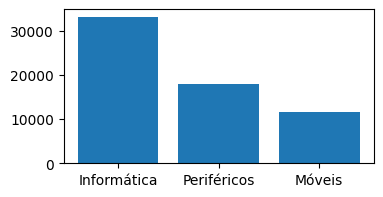

In [17]:
faturamento_por_categoria = df.groupby("categoria")["faturamento"].sum()
faturamento_por_categoria = faturamento_por_categoria.sort_values(ascending=False)

plt.figure(figsize=(4,2))
plt.bar(faturamento_por_categoria.index, faturamento_por_categoria.values)
plt.show()

Também podemos calcular a quantidade total vendida por produto.

In [18]:
quantidade_por_produto = df.groupby("produto")["quantidade"].sum().sort_values(ascending=False)
quantidade_por_produto

produto
Mouse       53
Teclado     33
Headset     18
Monitor     11
Webcam      11
Cadeira      9
Mesa         5
Notebook     5
Name: quantidade, dtype: int64

# 4. Introdução à Visualização de Dados

Visualizar dados significa transformar números e tabelas em gráficos.

Um bom gráfico deve ajudar a responder uma pergunta.

Antes de criar um gráfico, sempre pense:

1. Qual pergunta eu quero responder?
2. Quais colunas preciso usar?
3. Qual tipo de gráfico combina com essa pergunta?
4. O gráfico está claro para quem vai ler?

# 5. Matplotlib

O Matplotlib é uma biblioteca muito usada para criar gráficos em Python.

Ele oferece bastante controle sobre o gráfico, mas normalmente exige mais configuração manual.

## 5.1 Gráfico de barras com Matplotlib

Pergunta:

> Qual categoria teve maior faturamento?

Como queremos comparar categorias, um gráfico de barras é uma boa escolha.

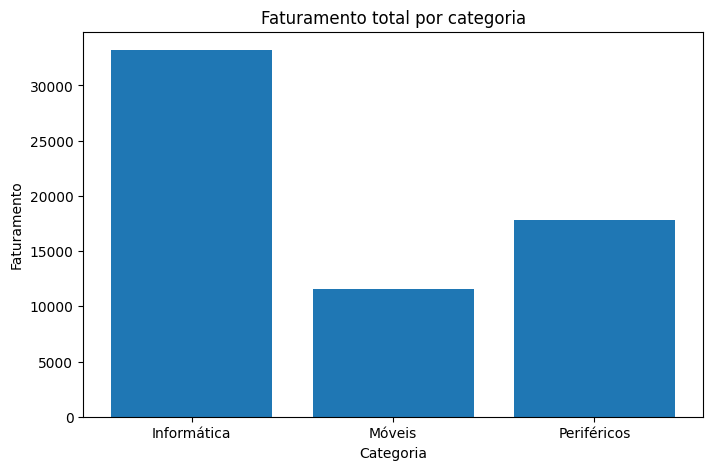

In [19]:
faturamento_por_categoria = df.groupby("categoria")["faturamento"].sum()

plt.figure(figsize=(8, 5))
plt.bar(faturamento_por_categoria.index, faturamento_por_categoria.values)
plt.title("Faturamento total por categoria")
plt.xlabel("Categoria")
plt.ylabel("Faturamento")
plt.show()

## 5.2 Gráfico de linha com Matplotlib

Pergunta:

> Como o faturamento evoluiu ao longo dos meses?

Quando queremos observar evolução ao longo do tempo, o gráfico de linha costuma ser uma boa escolha.

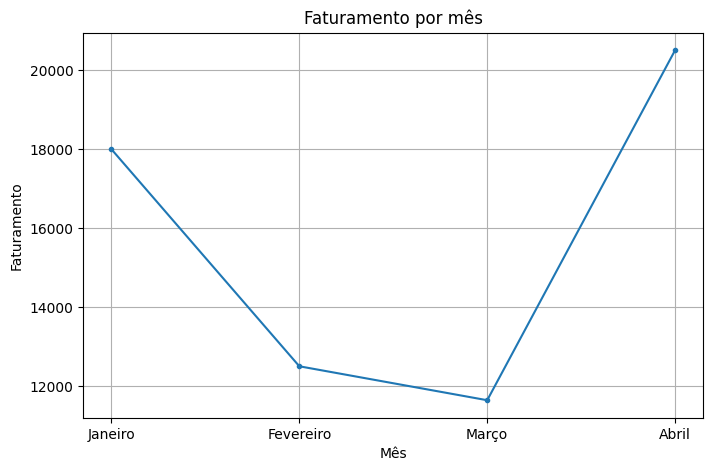

In [24]:
ordem_meses = ["Janeiro", "Fevereiro", "Março", "Abril"]

faturamento_por_mes = (
    df.groupby("mes")["faturamento"]
    .sum()
    .reindex(ordem_meses)
)

plt.figure(figsize=(8, 5))
plt.plot(faturamento_por_mes.index, faturamento_por_mes.values, marker=".")
plt.title("Faturamento por mês")
plt.xlabel("Mês")
plt.ylabel("Faturamento")
plt.grid(True)
plt.show()

## 5.3 Histograma com Matplotlib

Pergunta:

> Como os preços dos produtos estão distribuídos?

O histograma é usado para observar a distribuição de valores numéricos.

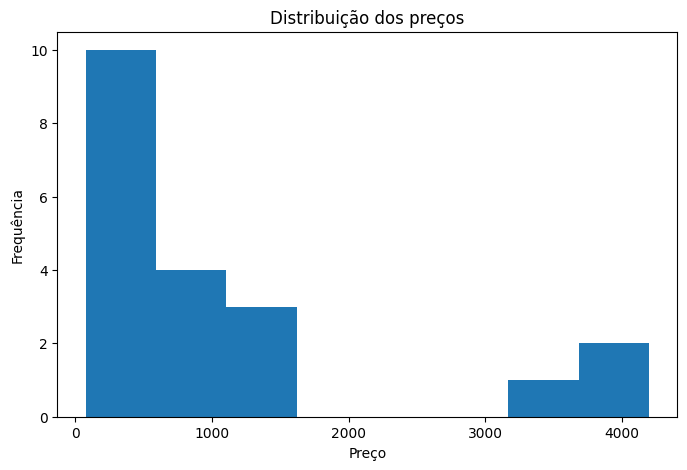

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(df["preco"], bins=8)
plt.title("Distribuição dos preços")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

## 5.4 Gráfico de dispersão com Matplotlib

Pergunta:

> Existe relação entre preço e quantidade vendida?

O gráfico de dispersão ajuda a visualizar a relação entre duas variáveis numéricas.

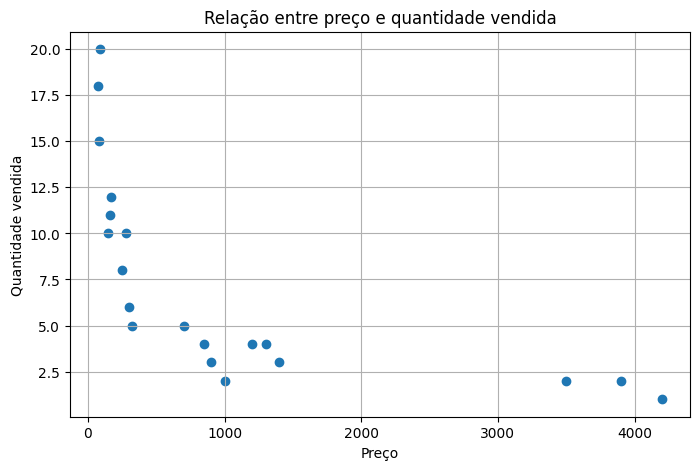

In [28]:
plt.figure(figsize=(8, 5))
plt.scatter(df["preco"], df["quantidade"])
plt.title("Relação entre preço e quantidade vendida")
plt.xlabel("Preço")
plt.ylabel("Quantidade vendida")
plt.grid(True)
plt.show()

# 6. Seaborn

O Seaborn é uma biblioteca baseada no Matplotlib.

Ele facilita a criação de gráficos estatísticos e geralmente produz gráficos visualmente melhores com menos código.

## 6.1 Gráfico de barras com Seaborn

Pergunta:

> Qual categoria teve maior faturamento?

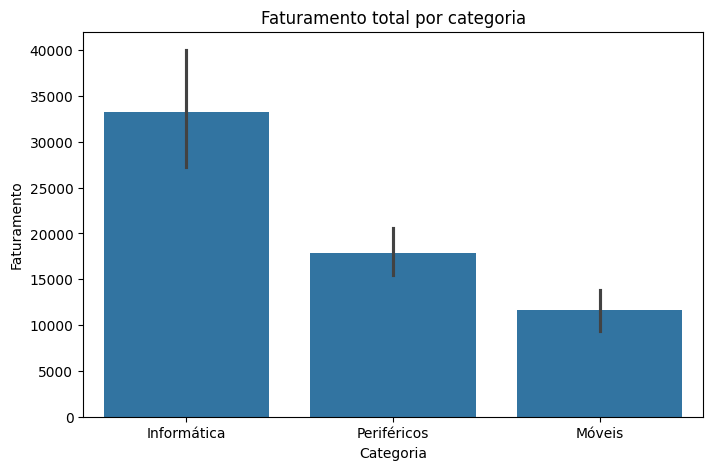

In [29]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="categoria", y="faturamento", estimator=sum)
plt.title("Faturamento total por categoria")
plt.xlabel("Categoria")
plt.ylabel("Faturamento")
plt.show()

## 6.2 Countplot

Pergunta:

> Quantas vendas existem por categoria?

O `countplot` conta a frequência de registros em uma coluna categórica.

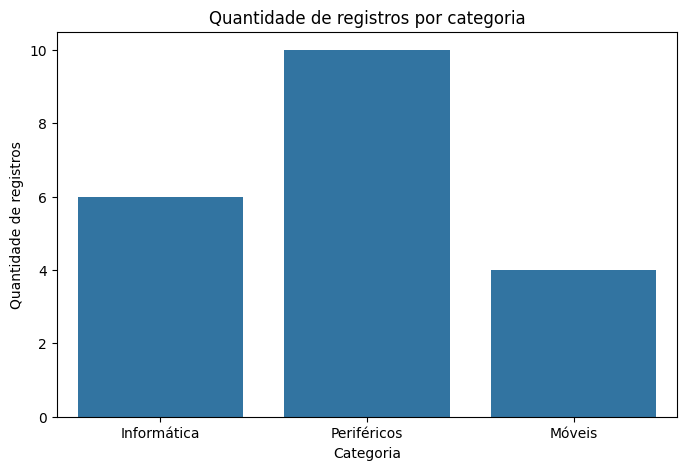

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="categoria")
plt.title("Quantidade de registros por categoria")
plt.xlabel("Categoria")
plt.ylabel("Quantidade de registros")
plt.show()

## 6.3 Histograma com Seaborn

Pergunta:

> Qual é a distribuição dos preços?

O Seaborn permite criar histogramas de forma simples com `histplot`.

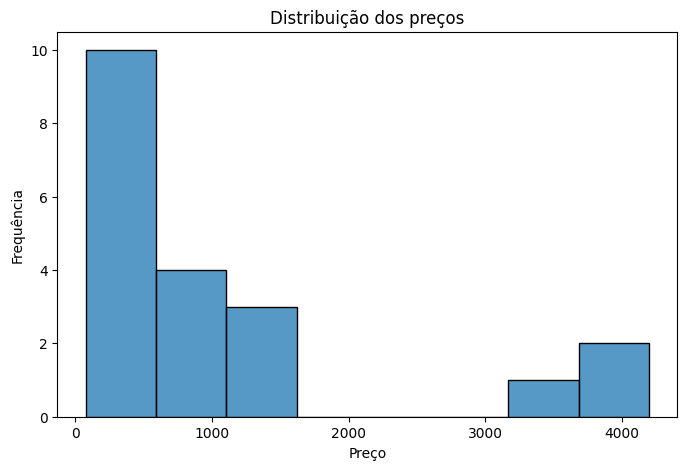

In [31]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="preco", bins=8)
plt.title("Distribuição dos preços")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

## 6.4 Boxplot

Pergunta:

> Existem preços muito altos ou muito baixos dentro de cada categoria?

O boxplot ajuda a visualizar:

- mediana;
- dispersão;
- possíveis outliers;
- variação dos dados.

     produto    categoria  preco  quantidade        mes  faturamento
0   Notebook  Informática   3500           2    Janeiro         7000
3    Monitor  Informática   1200           4    Janeiro         4800
8   Notebook  Informática   4200           1  Fevereiro         4200
11   Monitor  Informática   1400           3      Março         4200
16  Notebook  Informática   3900           2      Abril         7800
19   Monitor  Informática   1300           4      Abril         5200


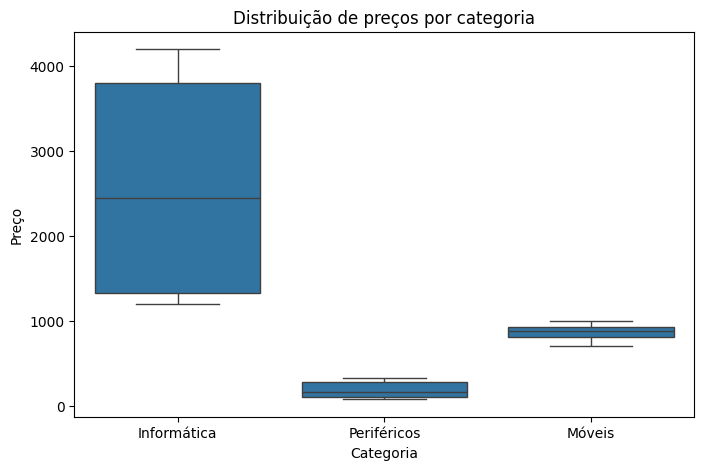

In [33]:
print(df[df["categoria"] == "Informática" ])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="categoria", y="preco")
plt.title("Distribuição de preços por categoria")
plt.xlabel("Categoria")
plt.ylabel("Preço")
plt.show()

## 6.5 Scatterplot com Seaborn

Pergunta:

> Existe relação entre preço e quantidade vendida?

Também podemos usar a cor para diferenciar categorias.

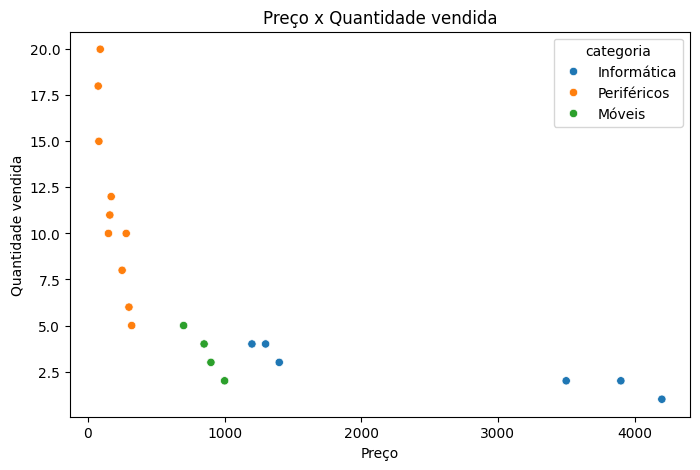

In [34]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="preco", y="quantidade", hue="categoria")
plt.title("Preço x Quantidade vendida")
plt.xlabel("Preço")
plt.ylabel("Quantidade vendida")
plt.show()

## 6.6 Heatmap de correlação

Pergunta:

> Quais variáveis numéricas parecem ter relação entre si?

A correlação mede o quanto duas variáveis numéricas variam juntas.

Valores próximos de:

- `1`: relação positiva forte;
- `0`: pouca ou nenhuma relação linear;
- `-1`: relação negativa forte.

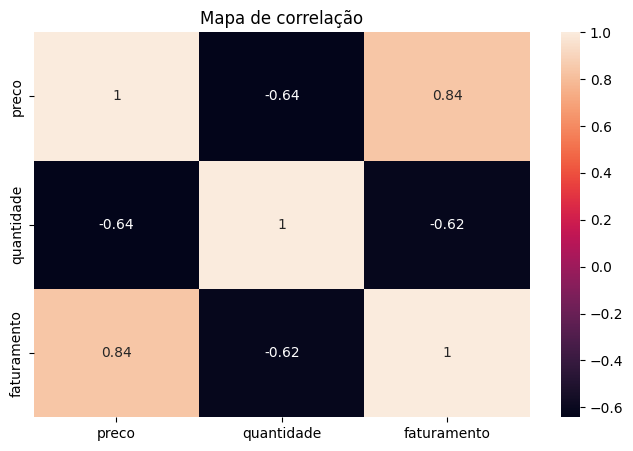

In [35]:
correlacao = df.corr(numeric_only=True)

plt.figure(figsize=(8, 5))
sns.heatmap(correlacao, annot=True)
plt.title("Mapa de correlação")
plt.show()

# 7. Escolhendo o gráfico correto

| Pergunta | Tipo de gráfico recomendado |
|---|---|
| Quero comparar categorias | Barras |
| Quero ver evolução no tempo | Linha |
| Quero entender distribuição de valores | Histograma |
| Quero encontrar outliers | Boxplot |
| Quero comparar duas variáveis numéricas | Dispersão |
| Quero ver correlação entre várias variáveis | Heatmap |

---

## Regra prática

Não escolha o gráfico porque ele é bonito.

Escolha o gráfico porque ele responde melhor à pergunta.

# 8. Exercícios guiados

Resolva os exercícios abaixo usando Pandas, Matplotlib e Seaborn.

## Exercício 1

Mostre os 5 produtos com maior faturamento total.

Dica:

- Use `groupby`;
- Some o faturamento por produto;
- Ordene do maior para o menor.

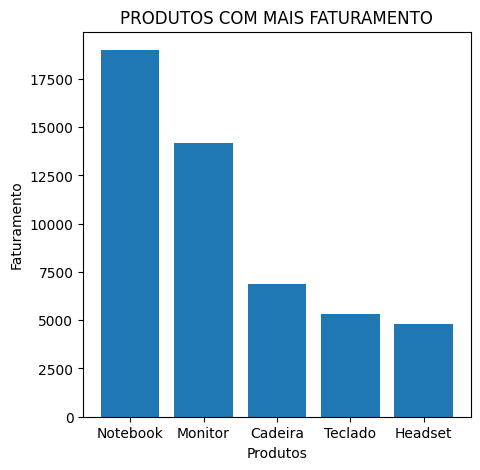

In [26]:
# Escreva sua solução aqui
faturamento_produtos = df.groupby("produto")["faturamento"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(5,5))
plt.bar(faturamento_produtos.index, faturamento_produtos.values)
plt.xlabel("Produtos")
plt.ylabel("Faturamento")
plt.title("PRODUTOS COM MAIS FATURAMENTO")
plt.show()

## Exercício 2

Crie um gráfico de barras mostrando o faturamento total por produto.

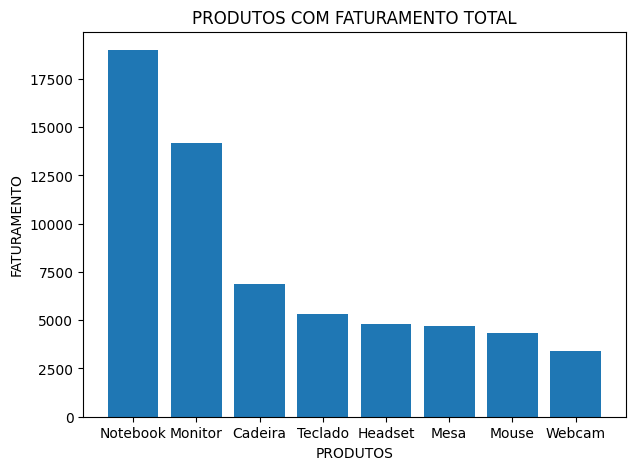

In [31]:
# Escreva sua solução aqui
faturamento_produtos = df.groupby("produto")["faturamento"].sum().sort_values(ascending=False)

plt.figure(figsize=(7,5))
plt.bar(faturamento_produtos.index, faturamento_produtos.values)
plt.xlabel("PRODUTOS")
plt.ylabel("FATURAMENTO")
plt.title("PRODUTOS COM FATURAMENTO TOTAL")
plt.show()

## Exercício 3

Crie um histograma para analisar a distribuição da quantidade vendida.

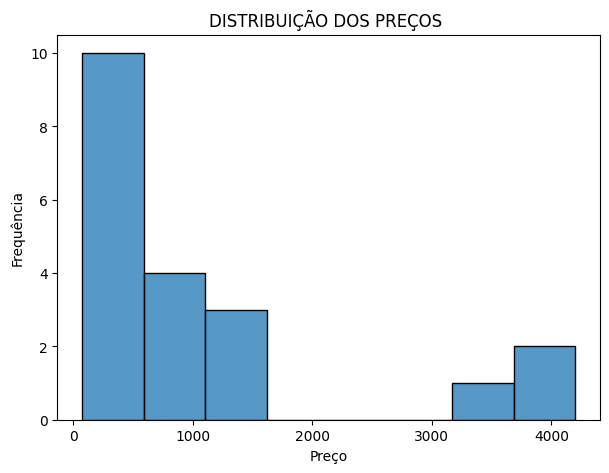

In [36]:
# Escreva sua solução aqui
plt.figure(figsize=(7, 5))
sns.histplot(data=df, x="preco", bins=8)
plt.title("DISTRIBUIÇÃO DOS PREÇOS ")
plt.xlabel("Preço")
plt.ylabel("Frequência")
plt.show()

## Exercício 4

Crie um boxplot comparando o faturamento por categoria.

Depois responda:

- Qual categoria parece ter maior variação?
- Existe algum valor muito fora do padrão?

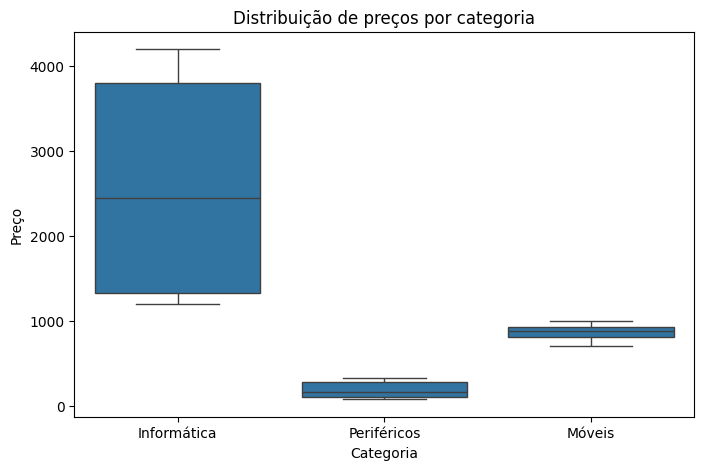

In [33]:
# Escreva sua solução aqui
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="categoria", y="preco")
plt.title("Distribuição de preços por categoria")
plt.xlabel("Categoria")
plt.ylabel("Preço")
plt.show()

## Exercício 5

Crie um gráfico de dispersão comparando preço e faturamento.

Depois responda:

- Produtos mais caros sempre geram maior faturamento?
- O que pode influenciar o faturamento além do preço?

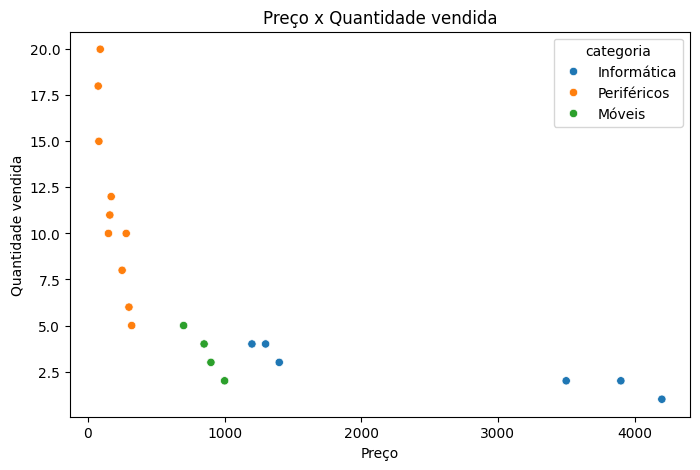

In [38]:
# Escreva sua solução aqui
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="preco", y="quantidade", hue="categoria")
plt.title("Preço x Quantidade vendida")
plt.xlabel("Preço")
plt.ylabel("Quantidade vendida")
plt.show()

# 9. Mini-desafio

Agora escolha uma pergunta própria sobre a base de dados.

Exemplos:

- Qual produto teve melhor desempenho?
- Qual mês teve maior faturamento?
- Qual categoria parece mais lucrativa?
- Existe relação entre preço e quantidade?
- Quais produtos merecem mais atenção da empresa?

Depois crie:

1. Uma pergunta de análise;
2. Um gráfico adequado;
3. Uma explicação do que o gráfico mostra;
4. Uma recomendação baseada nos dados.

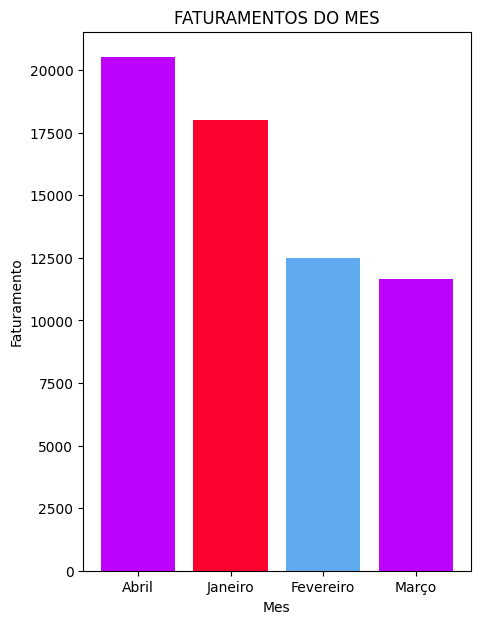

In [54]:
# Mini-desafio: escreva sua análise aqui
df #pergunta : Qual mes teve mais faturamento ? 
#grafico de barras 
faturamento_mes = df.groupby("mes")["faturamento"].sum().sort_values(ascending=False)

plt.figure(figsize=(5,7))
plt.bar(faturamento_mes.index, faturamento_mes.values , color=["#be03fc","#fc0330","#60aaf0"])
plt.xlabel("Mes")
plt.ylabel("Faturamento")
plt.title("FATURAMENTOS DO MES")
plt.show()

# 10. Conclusão

Nesta aula, revisamos:

- criação e leitura de DataFrames;
- exploração inicial dos dados;
- filtros;
- ordenação;
- agrupamentos;
- criação de colunas;
- gráficos com Matplotlib;
- gráficos com Seaborn;
- escolha do gráfico adequado para cada pergunta.
